<img src="https://devra.ai/analyst/notebook/2010/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">    <div style="font-size:150%; color:#FEE100"><b>Supply Chain Data Analysis and Prediction</b></div>    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

## Table of Contents

- [Introduction](#Introduction)
- [Imports and Setup](#Imports-and-Setup)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Conclusion and Future Work](#Conclusion-and-Future-Work)

## Introduction

The supply chain management data we analyze here covers a diverse array of attributes from product details to shipping logistics. It is intriguing to note that the dataset encapsulates everything from pricing metrics to manufacturing costs, providing rich ground for both exploratory analysis and predictive modeling. If you find these insights valuable, please consider upvoting this notebook.

In [1]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Ensuring a non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt is imported

# Enable inline plotting for Jupyter notebooks
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style='whitegrid')  # Set a seaborn style for all plots

In [2]:
# Data Loading
file_path = '/kaggle/input/supply-chain-dataset/supply_chain_data.csv'

# The file is ASCII encoded and comma delimited
df = pd.read_csv(file_path, delimiter=',', encoding='ascii')

print('Data loaded successfully, shape:', df.shape)
df.head()

Data loaded successfully, shape: (100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Data Cleaning and Preprocessing
print('Missing values per column:')
print(df.isnull().sum())

# Since the dataset does not explicitly include any date columns, we do not perform date parsing.
# However, if you come across date columns in similar datasets, consider using pd.to_datetime()

# For numeric analyses, reduce the dataframe to only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
print('Numeric DataFrame shape:', numeric_df.shape)

Missing values per column:
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64
Numeric DataFrame shape: (100, 15)


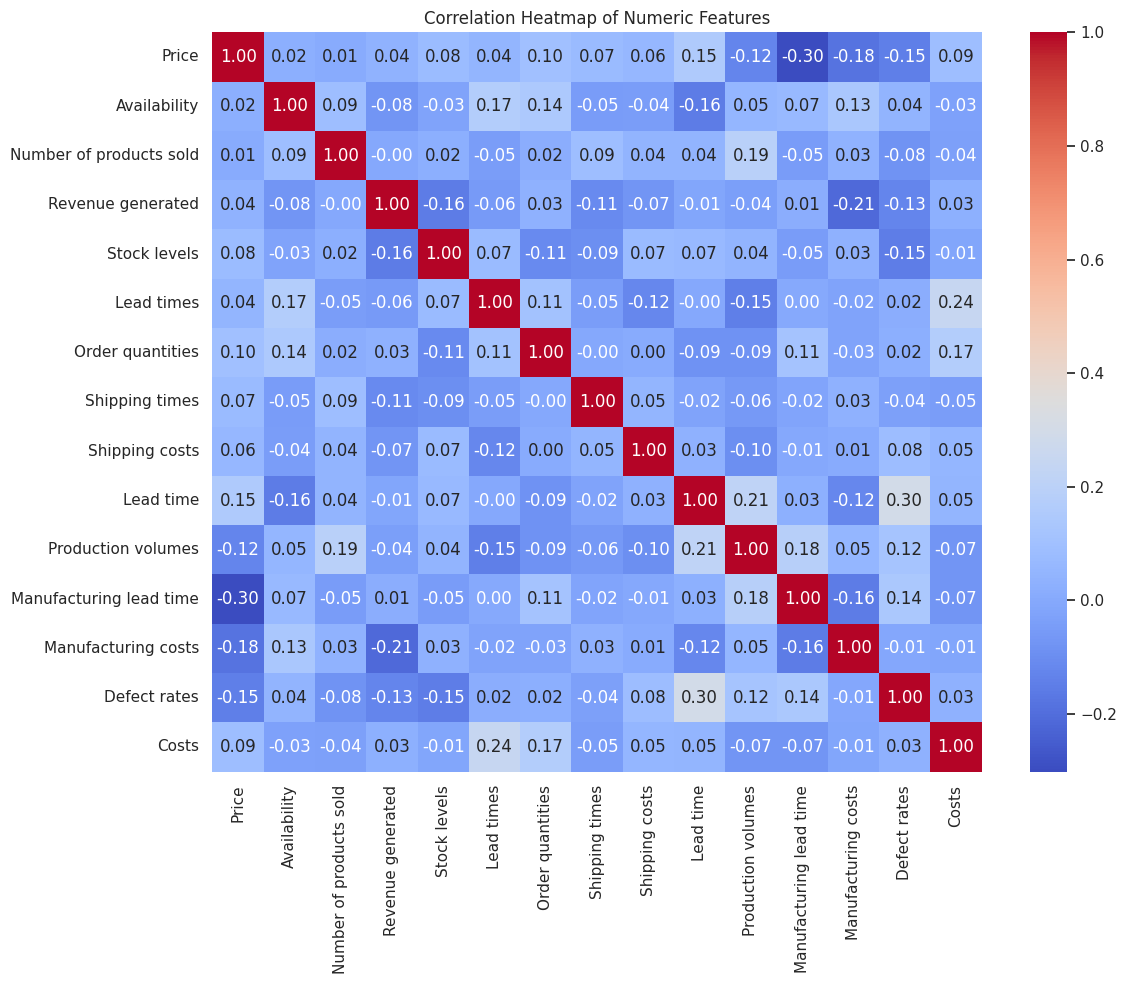

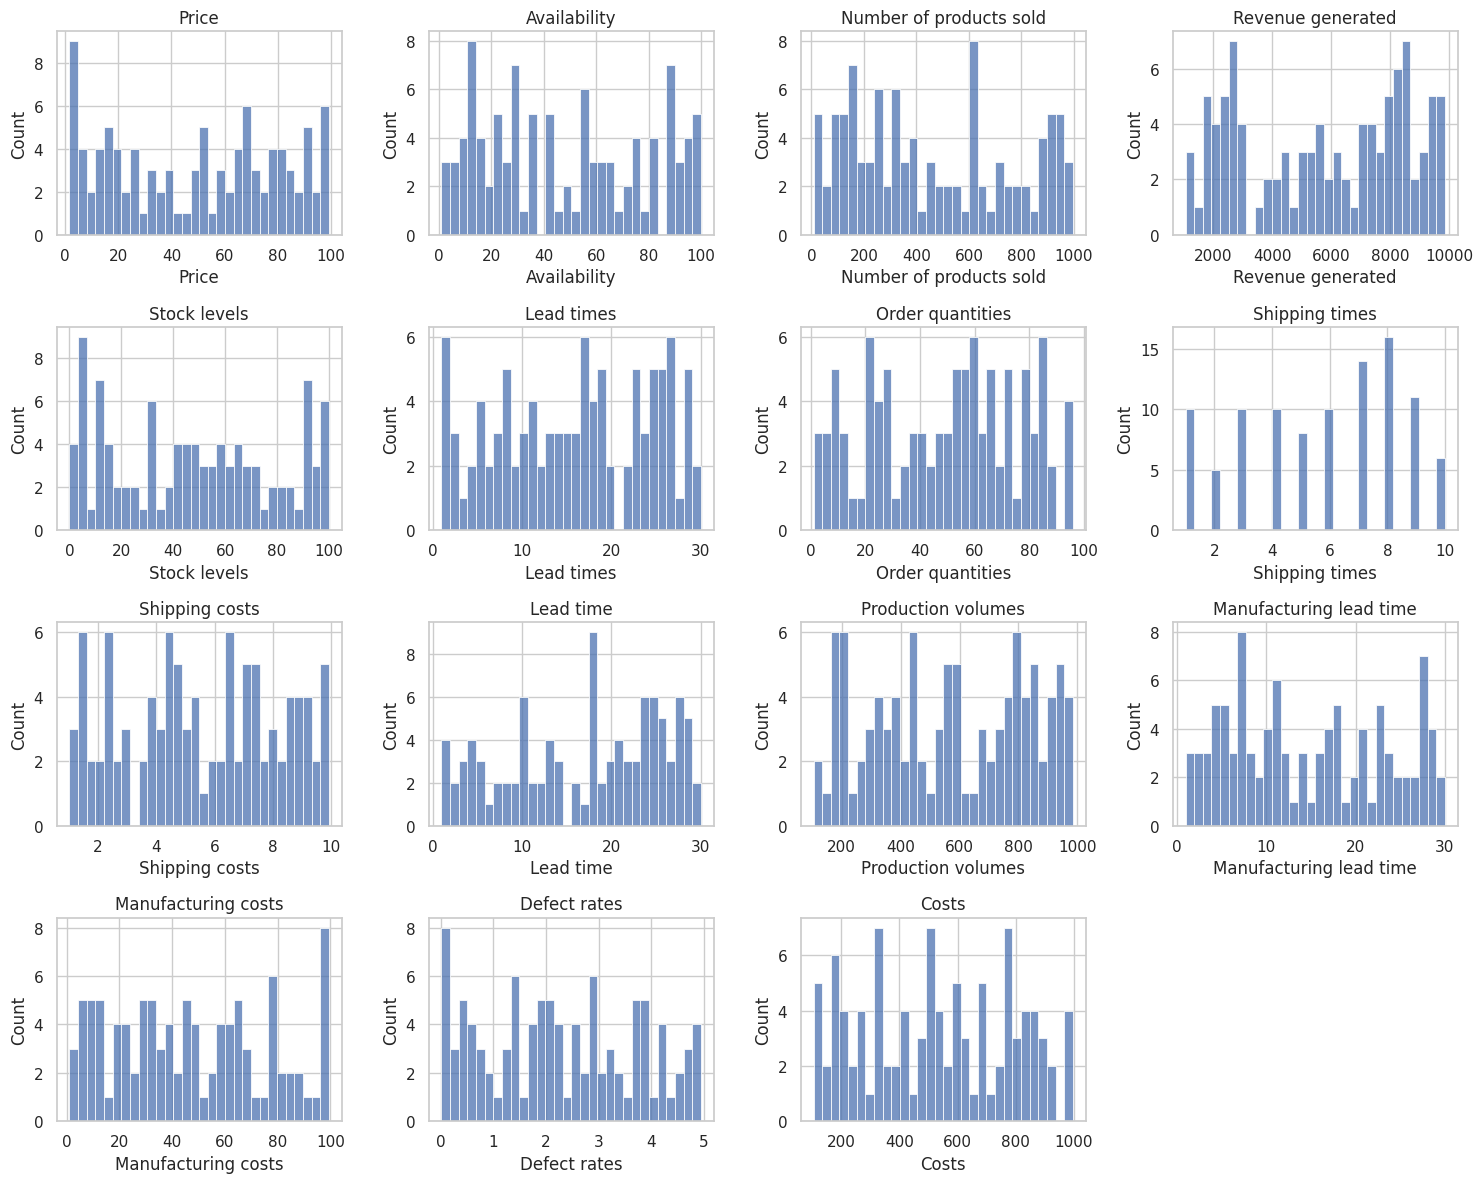

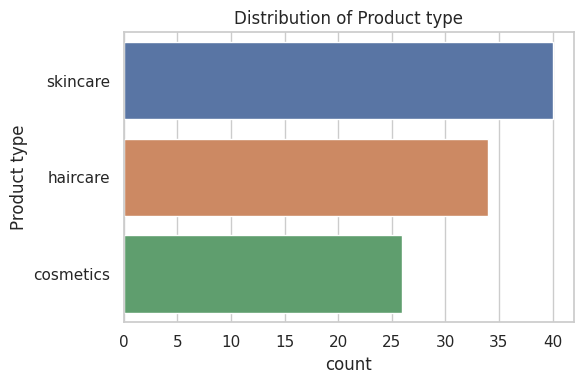

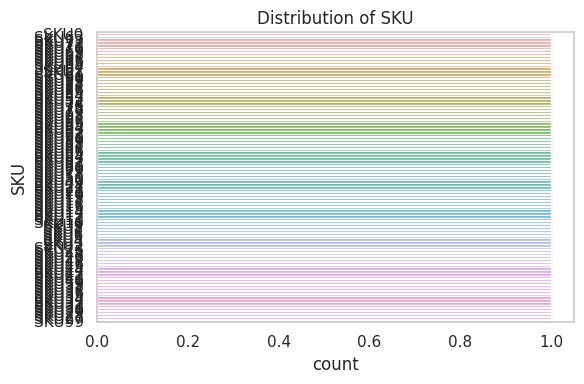

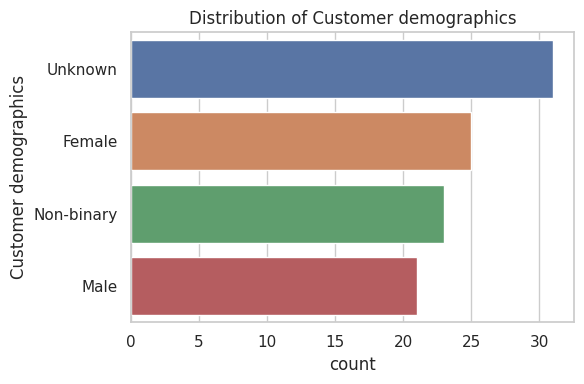

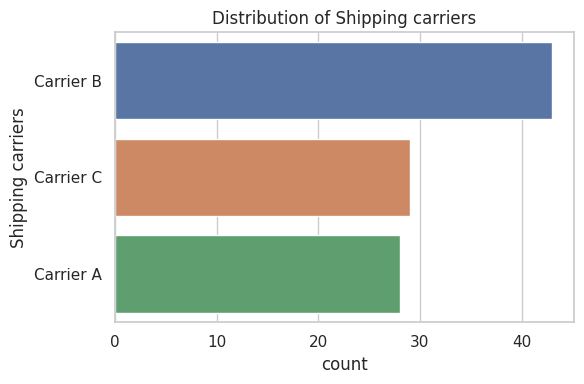

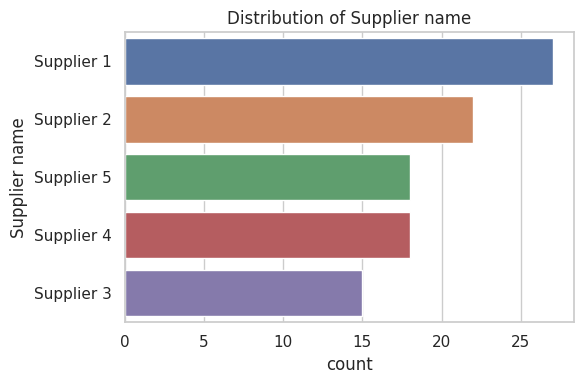

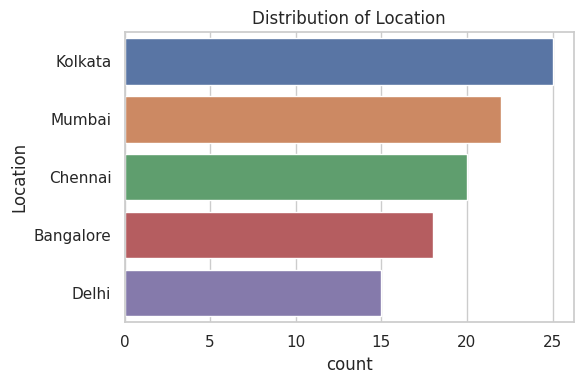

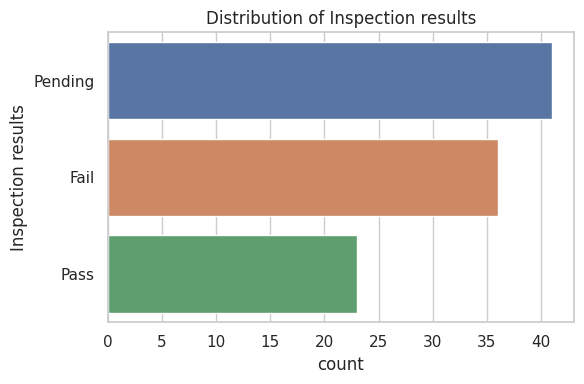

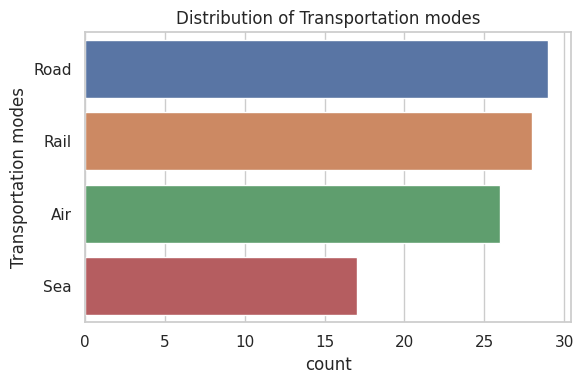

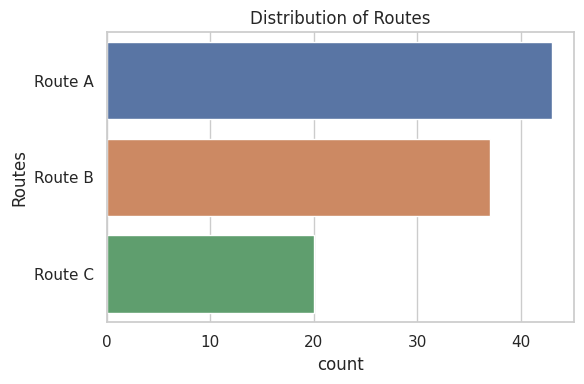

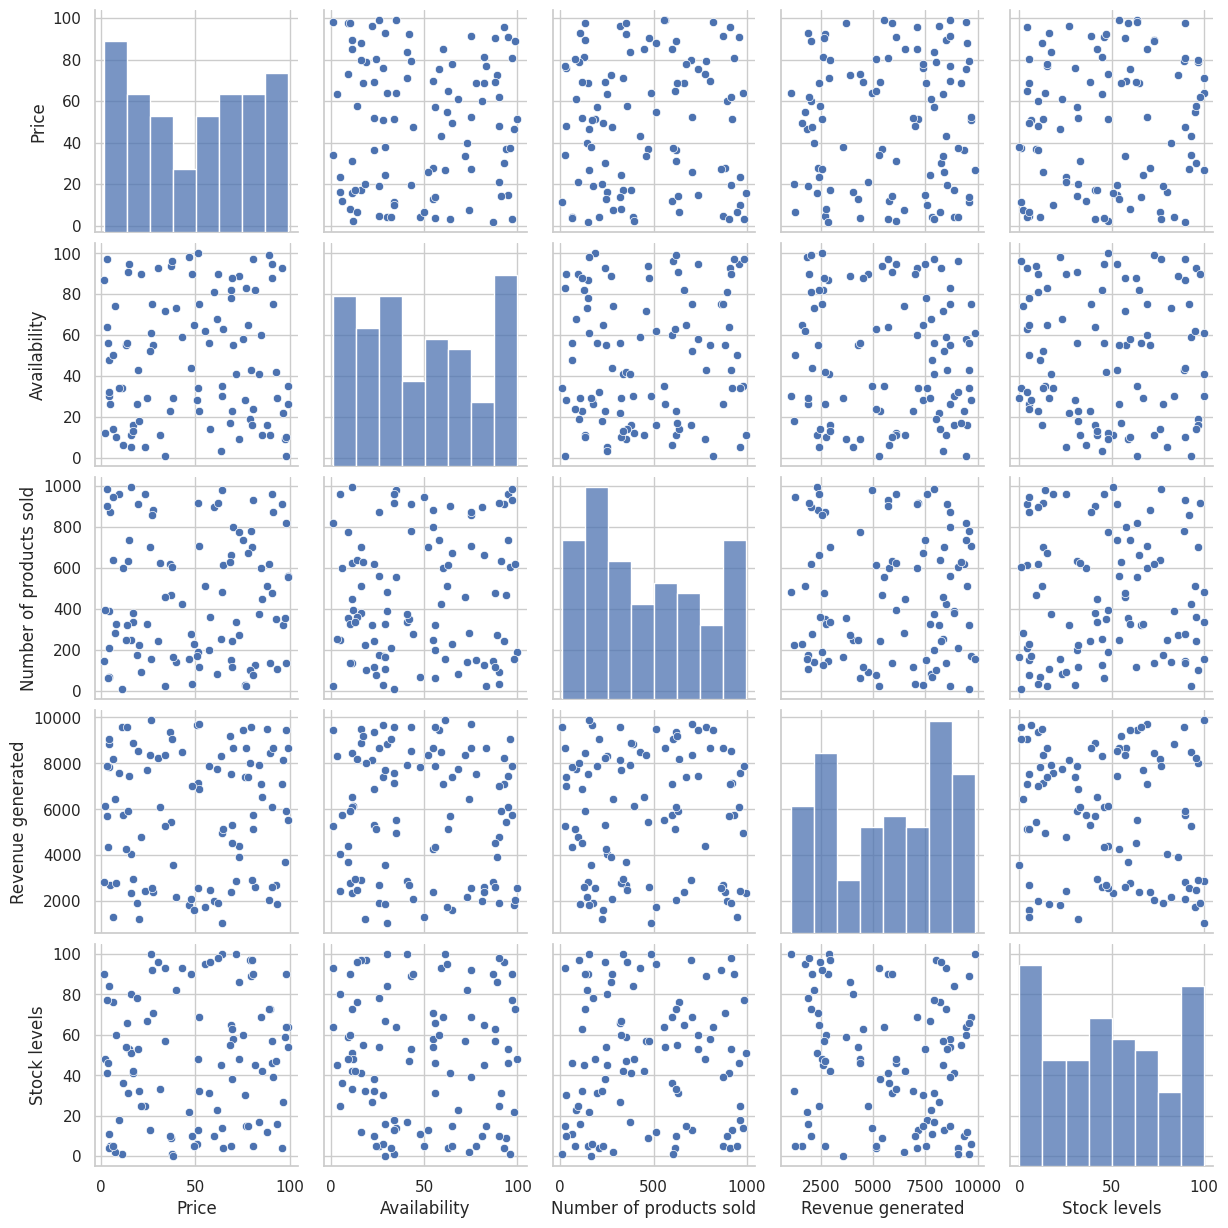

In [4]:
# Exploratory Data Analysis

## Correlation Heatmap
# Only perform correlation heatmap if there are four or more numeric columns
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

## Histograms for numeric features
numeric_columns = numeric_df.columns
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_columns):
    plt.subplot(4, 4, i+1)
    sns.histplot(numeric_df[col], kde=False, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

## Pie Chart / Countplot for categorical features
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Pair Plot for selected numeric features (sample if too many)
if len(numeric_columns) > 4:
    sample_columns = numeric_columns[:5]
else:
    sample_columns = numeric_columns
sns.pairplot(numeric_df[sample_columns])
plt.show()

Linear Regression R2 Score: -0.053


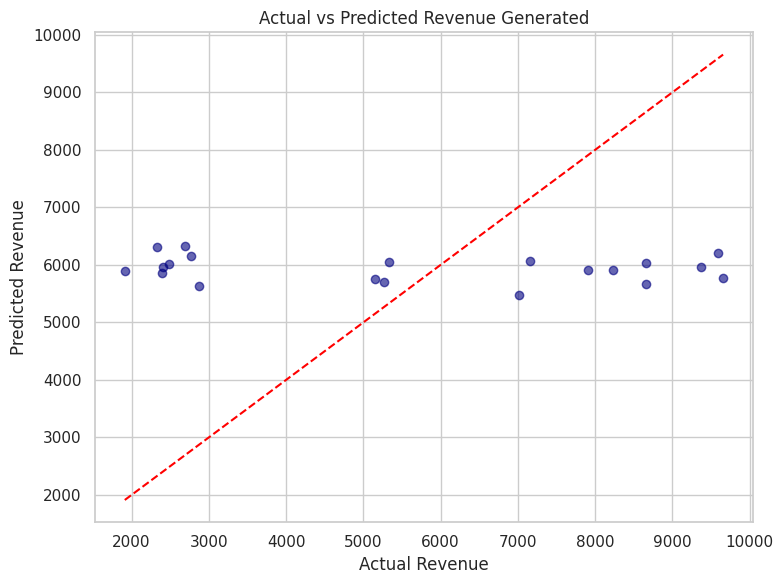

In [5]:
# Predictive Modeling

## For this example, we predict 'Revenue generated' based on other numeric features.
## It is a simple linear regression model. Note that improvement can be made by engineering features

# Selecting features and target
target = 'Revenue generated'

# For predictor variables, we'll use a subset of numeric features that are likely related
features = ['Price', 'Number of products sold', 'Shipping costs', 'Costs']

# Check if all selected features exist
for feat in features + [target]:
    if feat not in df.columns:
        raise ValueError(f"Column '{feat}' not found in the dataset.")

X = df[features].copy()
y = df[target].copy()

# Handle potential missing values - in case there are any.
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate using R2 score (as a measure of goodness-of-fit)
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"Linear Regression R2 Score: {score:.3f}")

# Plot predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='navy')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue Generated')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.tight_layout()
plt.show()

## Conclusion and Future Work

This notebook demonstrated an analysis of a supply chain dataset by progressively cleaning and exploring the data using visualizations, and ultimately building a basic linear regression model to predict revenue. The approach included several standard visualization techniques, ensuring the data was suitably prepared for modeling.

Future work could include: 

- Experimenting with more robust predictive models such as decision trees or ensemble methods.
- Further feature engineering to incorporate categorical variables through encoding.
- Analyzing time series data if date columns are available in future iterations of this dataset.

If this notebook has been helpful, please consider upvoting it.